# Trabajo Final AMq1


Participantes:

*   a2412 | Martín Gabriel Quiroga
*   a2407 | Mariano Jauffroy
*   a2406 | Andrés Pablo García



## 1. Introducción

El presente trabajo se basa en un dataset de clasificación de objetos astronómicos publicado en Kaggle, que contiene observaciones provenientes del Sloan Digital Sky Survey (SDSS). Cada registro corresponde a mediciones fotométricas y espectroscópicas de distintos cuerpos celestes, a partir de las cuales se asigna una etiqueta en la variable objetivo Class, que distingue entre estrellas, galaxias y cuásares.

Dataset: https://www.kaggle.com/datasets/fedesoriano/stellar-classification-dataset-sdss17/data

El objetivo principal consiste en desarrollar e implementar distintos modelos de machine learning capaces de predecir la clasificación de los objetos a partir de sus características físicas observadas.

A lo largo del trabajo se presentan las distintas etapas del proceso, siguiendo el flujo típico de un problema de aprendizaje supervisado: análisis exploratorio de datos, preprocesamiento, entrenamiento de modelos y evaluación de resultados. En cada sección se incluyen las decisiones metodológicas adoptadas, así como las observaciones y conclusiones derivadas del análisis.

## Imports

In [1]:
%pip install optuna
%pip install xgboost

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from matplotlib import colors
import math

from sklearn.model_selection import GroupShuffleSplit

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    balanced_accuracy_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

import optuna
from sklearn.model_selection import cross_val_score

from sklearn.utils import resample

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import xgboost as xgb
from xgboost import XGBClassifier

## 2. EDA

### 2.1. Descripción de Kaggle

**Contexto**

En astronomía, la clasificación estelar consiste en categorizar las estrellas en función de sus características espectrales. El esquema de clasificación de galaxias, cuásares y estrellas es uno de los más fundamentales dentro de la disciplina.

Los primeros catálogos de estrellas y su distribución en el cielo permitieron comprender que forman parte de nuestra propia galaxia. Posteriormente, al descubrirse que Andrómeda era una galaxia distinta de la nuestra, comenzaron a estudiarse numerosas galaxias a medida que se desarrollaban telescopios más potentes.

Este dataset tiene como objetivo clasificar estrellas, galaxias y cuásares a partir de sus características espectrales.

**Contenido**

El dataset contiene 100.000 observaciones del espacio obtenidas por el Sloan Digital Sky Survey (SDSS). Cada observación está descrita por 17 variables predictoras (features) y 1 variable objetivo (class) que indica si el objeto es una estrella, una galaxia o un cuásar.

**A continuación se describen las variables**:

* obj_ID: Identificador del objeto. Valor único que identifica el objeto en el catálogo de imágenes del CAS.
* alpha: Ascensión recta (Right Ascension) en el sistema de coordenadas celestes (época J2000).
* delta: Declinación en el sistema de coordenadas celestes (época J2000).
* u: Filtro ultravioleta del sistema fotométrico.
* g: Filtro verde del sistema fotométrico.
* r: Filtro rojo del sistema fotométrico.
* i: Filtro infrarrojo cercano.
* z: Filtro infrarrojo.
* run_ID: Identificador de la corrida de observación.
* rerun_ID: Identificador del reprocesamiento de la imagen.
* cam_col: Columna de la cámara que identifica la línea de escaneo dentro de la corrida.
* field_ID: Identificador del campo observado.
* spec_obj_ID: Identificador único de objetos espectroscópicos. Dos observaciones con el mismo valor deben tener la misma clase.
* class: Clase del objeto (galaxia, estrella o cuásar).
* redshift: Corrimiento al rojo, asociado al aumento en la longitud de onda.
* plate: Identificador de la placa utilizada en el SDSS.
* MJD: Fecha en formato Modified Julian Date, que indica cuándo se tomó la observación.
* fiber_ID: Identificador de la fibra óptica utilizada para capturar la luz en el plano focal.

### 2.2. Análisis Inicial

In [3]:
url = "https://raw.githubusercontent.com/gabrielquiroga/ceia-amq1-tf/main/dataset/star_classification.csv"
df = pd.read_csv(url)

In [4]:
df.columns

Index(['obj_ID', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID',
       'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'class', 'redshift',
       'plate', 'MJD', 'fiber_ID'],
      dtype='object')

In [5]:
df.shape

(100000, 18)

In [6]:
df.head(5)

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7),

### 2.3. Duplicados

In [8]:
df.duplicated().sum()
# no hay duplicados

np.int64(0)

No hay registros completamente duplicados

In [9]:
df.nunique()

,0
obj_ID,78053
alpha,99999
delta,99999
u,93748
g,92651
r,91901
i,92019
z,92007
run_ID,430
rerun_ID,1


El dataset contiene 100.000 registros correspondientes a 78.053 objetos celestes distintos. Esto implica que, para algunos objetos, existen múltiples mediciones.

Esta característica introduce una consideración importante al momento de realizar el train-test split, ya que incluir mediciones de un mismo objeto tanto en entrenamiento como en prueba puede generar data leakage. En consecuencia, resulta conveniente agrupar por obj_ID y asegurar que todas las observaciones de un mismo objeto pertenezcan al mismo subconjunto.

Por otro lado, se observa que en algunos casos un mismo objeto presenta distintas etiquetas en la variable objetivo (class). Este comportamiento puede interpretarse de dos maneras, dependiendo del objetivo del modelo:

* Si el objetivo es identificar correctamente el tipo de objeto celeste, estas inconsistencias deberían tratarse como ruido a corregir.
* Si el objetivo es modelar el resultado de las mediciones del instrumento, entonces este comportamiento puede considerarse parte del fenómeno a aprender.

### 2.4. Nulos

No hay nulos

In [10]:
df.isnull().sum()
# no hay nulos

,0
obj_ID,0
alpha,0
delta,0
u,0
g,0
r,0
i,0
z,0
run_ID,0
rerun_ID,0


### 2.5. Outliers

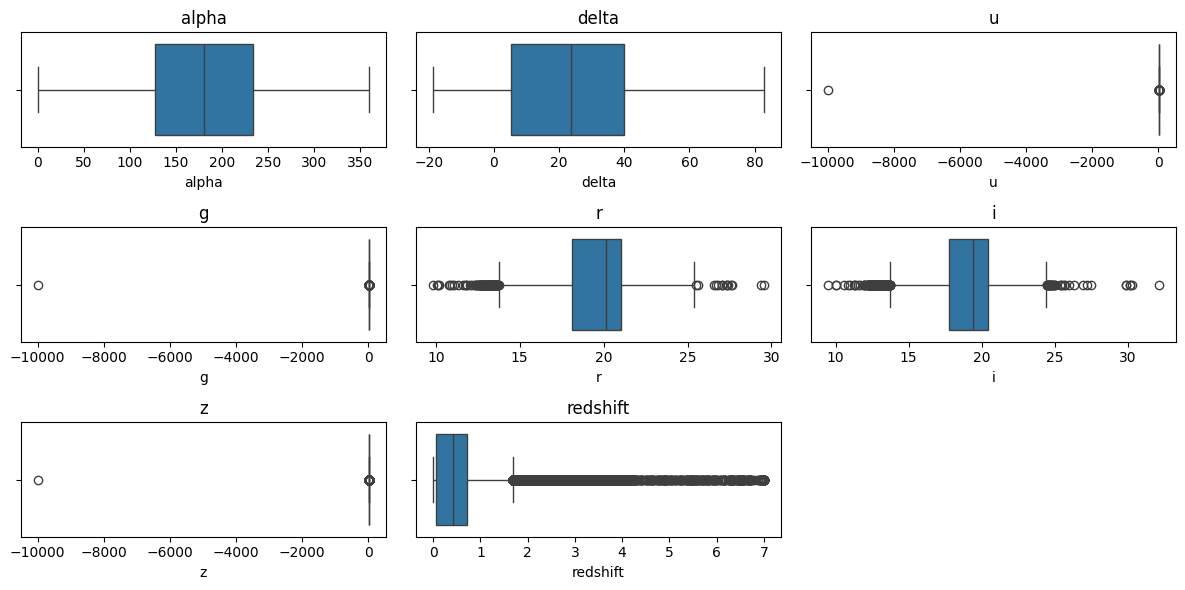

In [11]:
cols = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z','redshift']
n_cols = 3  # cantidad de gráficos por fila
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 2 * n_rows))

axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

# eliminar ejes vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [12]:
# investigamos el outlier negativo de u, g y z

df[df['u'] < 0]

# se observa que corresponde al mismo registro
# este registro será eliminado en la preparación del dataset

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
79543,1.237649e+18,224.006526,-0.624304,-9999.0,-9999.0,18.1656,18.01675,-9999.0,752,301,2,537,3.731277e+18,STAR,0.000089,3314,54970,162


### 2.6. Conclusiones EDA

A partir del análisis exploratorio, se adoptan las siguientes decisiones de preprocesamiento:

En primer lugar, se opta por resolver las inconsistencias en la variable objetivo eliminando, para cada obj_ID, las observaciones correspondientes a la clase minoritaria y conservando únicamente la clase mayoritaria. Esto permite reducir el ruido en las etiquetas y facilitar el aprendizaje del modelo.

En segundo lugar, el train-test split se realizará respetando la agrupación por obj_ID, de modo de evitar la presencia de mediciones del mismo objeto en ambos conjuntos.

Finalmente, se decide trabajar inicialmente únicamente con variables físicas (como magnitudes en distintas bandas y redshift), ya que estas describen directamente las propiedades de los objetos celestes. Las variables asociadas al instrumento (run_ID, cam_col, field_ID, plate, fiber_ID) no representan características intrínsecas del objeto, sino del proceso de medición. Sin embargo, se considerarán en Random Forest con el objetivo de analizar su impacto en la performance.

| Variable      | Tipo           | Decisión                      | Motivo                                                                                                              |
| ------------- | -------------- | ----------------------------- | ------------------------------------------------------------------------------------------------------------------- |
| `obj_ID`      | ID objeto      | ❌ Drop (usar solo para split) | Identificador. Sirve para agrupar observaciones del mismo objeto y evitar leakage, pero no aporta señal predictiva. |
| `spec_obj_ID` | ID observación | ❌ Drop                        | Alta cardinalidad (100k únicos). Es prácticamente un identificador de fila. Riesgo alto de overfitting.             |
| `alpha`       | Física         | ✅ Keep                        | Posición en el cielo (ascensión recta). Puede aportar información espacial relevante.                               |
| `delta`       | Física         | ✅ Keep                        | Posición en el cielo (declinación). Complementa `alpha`.                                                            |
| `u`           | Fotométrica    | ✅ Keep                        | Intensidad en ultravioleta. Clave para distinguir tipos de objetos.                                                 |
| `g`           | Fotométrica    | ✅ Keep                        | Banda verde.                                                                                                        |
| `r`           | Fotométrica    | ✅ Keep                        | Banda roja.                                                                                                         |
| `i`           | Fotométrica    | ✅ Keep                        | Infrarrojo cercano.                                                                                                 |
| `z`           | Fotométrica    | ✅ Keep                        | Infrarrojo.                                                                                                         |
| `redshift`    | Física         | ✅ Keep (MUY importante)       | Relacionado con distancia/expansión. Altamente discriminativo (ej: quasars suelen tener redshift alto).             |
| `run_ID`      | Instrumental   | ⚠️ Drop (Probar RF)            | Identifica corrida del telescopio. Puede introducir sesgo del instrumento.                                          |
| `rerun_ID`    | Instrumental   | ❌ Drop                        | Constante (1 valor). No aporta información.                                                                         |
| `cam_col`     | Instrumental   | ⚠️ Drop (Probar RF)            | Parte de la cámara. Riesgo de aprender artefactos del sensor.                                                       |
| `field_ID`    | Instrumental   | ⚠️ Drop (Probar RF)            | Segmento del cielo medido. Puede correlacionar con distribución observacional, no física.                           |
| `plate`       | Instrumental   | ⚠️ Drop (Probar RF)            | Configuración del telescopio. Riesgo de sesgo experimental.                                                         |
| `fiber_ID`    | Instrumental   | ⚠️ Drop (Probar RF)            | Parte del sistema óptico. No describe el objeto.                                                                    |
| `MJD`         | Temporal       | ⚠️ Drop (Probar RF)            | Momento de medición. Puede capturar drift o sesgos temporales.                                                      |
| `class`       | Target         | 🎯 Keep                       | Variable objetivo (star, galaxy, quasar).                                                                           |

## 3. Preparación del dataset

### 3.1. Tratamiento outliers y eliminación de clases minoritarias

In [13]:
# se elimina el outlier detectado en la etapa anterior

anomalias = df[(df['u'] == -9999) | (df['g'] == -9999) | (df['z'] == -9999)]
df = df[(df['u'] != -9999) & (df['g'] != -9999) & (df['z'] != -9999)]

In [14]:
# ============================================================
# Generación del DataFrame 1: Clase mayoritaria por obj_ID
# ============================================================

# 1. Identificar grupos con más de un registro por obj_ID
group_counts = df.groupby('obj_ID').size()
duplicated_obj_ids = group_counts[group_counts > 1].index
unique_obj_ids = group_counts[group_counts == 1].index

print(f"Total de obj_IDs únicos: {df['obj_ID'].nunique()}")
print(f"obj_IDs con un solo registro: {len(unique_obj_ids)}")
print(f"obj_IDs con múltiples registros: {len(duplicated_obj_ids)}")
print(f"Total de registros en el dataset original: {len(df)}")
print("=" * 70)

# 2. Analizar la situación de cada grupo con múltiples registros
rows_to_keep = []
total_discarded = 0

for obj_id in duplicated_obj_ids:
    group = df[df['obj_ID'] == obj_id]
    class_counts = group['class'].value_counts()

    # Verificar si hay más de una clase en el grupo
    has_conflict = len(class_counts) > 1
    majority_class = class_counts.idxmax()
    majority_count = class_counts.max()
    total_in_group = len(group)

    if has_conflict:
        minority_count = total_in_group - majority_count
        total_discarded += minority_count
        # print(f"\n🔀 obj_ID: {obj_id}")
        # print(f"   Total registros: {total_in_group}")
        # print(f"   Distribución de clases: {dict(class_counts)}")
        # print(f"   Clase mayoritaria: '{majority_class}' ({majority_count} registros)")
        # print(f"   Registros descartados (clases minoritarias): {minority_count}")

    # Conservar solo los registros de la clase mayoritaria
    rows_to_keep.append(group[group['class'] == majority_class])

# 3. Agregar los registros de obj_IDs únicos (sin duplicados)
unique_rows = df[df['obj_ID'].isin(unique_obj_ids)]

# 4. Construir el DataFrame filtrado
df_majority = pd.concat([unique_rows] + rows_to_keep, ignore_index=True)

print("\n" + "=" * 70)
print("RESUMEN FINAL")
print("=" * 70)
print(f"Registros originales: {len(df)}")
print(f"Registros descartados por clase minoritaria: {total_discarded}")
print(f"Registros en df_majority: {len(df_majority)}")
print(f"\nDistribución de clases en df original:")
print(df['class'].value_counts())
print(f"\nDistribución de clases en df_majority:")
print(df_majority['class'].value_counts())

Total de obj_IDs únicos: 78052
obj_IDs con un solo registro: 62693
obj_IDs con múltiples registros: 15359
Total de registros en el dataset original: 99999

RESUMEN FINAL
Registros originales: 99999
Registros descartados por clase minoritaria: 6340
Registros en df_majority: 93659

Distribución de clases en df original:
class
GALAXY    59445
STAR      21593
QSO       18961
Name: count, dtype: int64

Distribución de clases en df_majority:
class
GALAXY    57928
STAR      19345
QSO       16386
Name: count, dtype: int64


### 3.2. Split del dataset

In [15]:
# se reliza el split tomando en cuenta de no "dividir"
# los diferentes registros de un mismo obj_ID para evitar data leakage
gss = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)

train_idx, test_idx = next(gss.split(df_majority, groups=df_majority['obj_ID']))

train_df = df_majority.iloc[train_idx]
test_df = df_majority.iloc[test_idx]

In [16]:
print(train_df.shape)
print(test_df.shape)

(74981, 18)
(18678, 18)


### 3.3. Selección de Features

In [17]:
# se seleccionan las variables físicas y fotométricas mencionadas en EDA

features = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']

X_train = train_df[features]
X_test = test_df[features]

y_train = train_df['class']
y_test = test_df['class']

### 3.4. Encoding de Target (categórica) y Escalado de Features

In [18]:
# Encoding de variable categórica
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [19]:
# Escalado de variables
# (necesario para modelos KNN y SVM)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 3.5. Utils

In [20]:
def show_metrics(y_true, y_pred, cm_classes = None, cm_title = "Matriz de confusión"):
  # Se imprimen las métricas
  cm = confusion_matrix(y_true, y_pred)

  disp_cm = ConfusionMatrixDisplay(
      confusion_matrix=cm,
      display_labels=cm_classes
  )

  fig, ax = plt.subplots(figsize=(6, 6))
  ax.grid = False
  disp_cm.plot(ax=ax)
  ax.set_title(cm_title)

  # Accuracy
  acc = accuracy_score(y_true, y_pred)

  # F1-score
  f1_macro = f1_score(y_true, y_pred, average='macro')
  f1_weighted = f1_score(y_true, y_pred, average='weighted')

  # Precision y Recall
  precision_macro = precision_score(y_true, y_pred, average='macro')
  recall_macro = recall_score(y_true, y_pred, average='macro')

  print("Accuracy:", acc)
  print("F1 (macro):", f1_macro)
  print("F1 (weighted):", f1_weighted)
  print("Precision (macro):", precision_macro)
  print("Recall (macro):", recall_macro)

## 4. Baseline

A partir de algunas observaciones durante el EDA, se destacó que el feature `redshift` mostraba una diferenciación importante entre clases, por lo cual se lo selecciona para armar un modelo base.

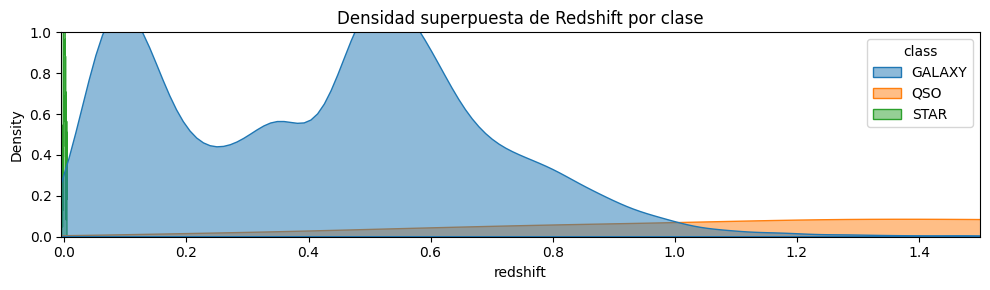

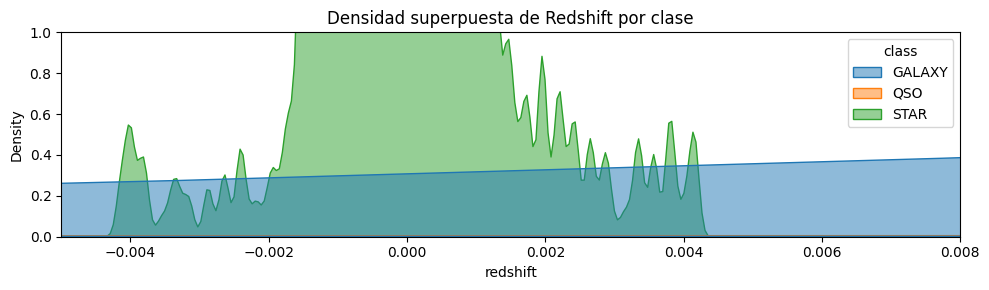

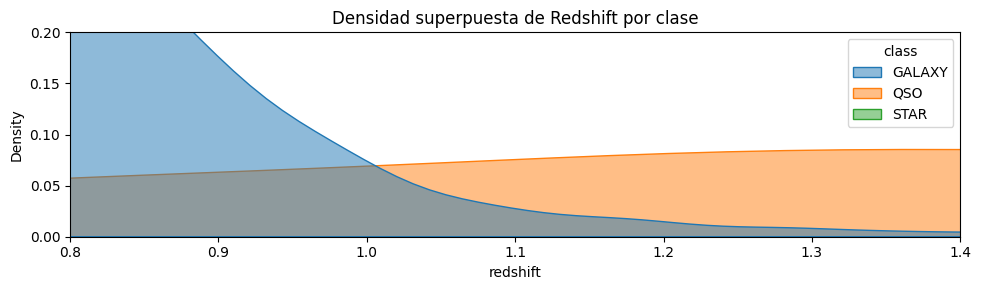

In [21]:
plt.figure(figsize=(10, 3))
sns.kdeplot(
    data=train_df,
    x='redshift',
    hue='class',
    fill=True,
    alpha=0.5,
)
plt.title('Densidad superpuesta de Redshift por clase')

plt.xlim(-0.005, 1.5)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 3))
sns.kdeplot(
    data=train_df,
    x='redshift',
    hue='class',
    fill=True,
    alpha=0.5,
)
plt.title('Densidad superpuesta de Redshift por clase')

plt.xlim(-0.005, 0.008)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 3))
sns.kdeplot(
    data=train_df,
    x='redshift',
    hue='class',
    fill=True,
    alpha=0.5,
)
plt.title('Densidad superpuesta de Redshift por clase')

plt.xlim(0.8, 1.4)
plt.ylim(0, 0.2)
plt.tight_layout()
plt.show()

A partir de la observación de los gráficos, se pueden definir los siguientes límites sobre el valor de `redshift` para separar las clases:
- $\text{Redshift} \leq 0.0044$ $\implies$ STAR
- $0.0044 < \text{Redshift} \leq 1.0$ $\implies$ GALAXY
- $1.0 < \text{Redshift}$ $\implies$ QSO

Para mejorar un poco este baseline se podría hacer un árbol de decisión con solo 3 hojas o hacer una búsqueda de grilla alrededor de los valores estimados visualmente. Procedemos con esta última alternativa, también con el objetivo de mantener el baseline simple.

In [22]:
cortes_1 = np.linspace(0.004, 0.005, 20)
cortes_2 = np.linspace(0.998, 1.002, 20)

best_accuracy = 0
best_cortes = None

for c1 in cortes_1:
    for c2 in cortes_2:
        bins = [-np.inf, c1, c2, np.inf]
        labels = ['STAR', 'GALAXY', 'QSO']

        preds = pd.cut(train_df['redshift'], bins=bins, labels=labels)

        accuracy = accuracy_score(train_df['class'], preds)

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_cortes = (c1, c2)

print("Mejores cortes: ", best_cortes)
print(f"Precisión: {best_accuracy:.4f}")

Mejores cortes:  (np.float64(0.004157894736842105), np.float64(1.0009473684210526))
Precisión: 0.9504


Ahora se hacen las predicciones sobre el dataset de test, usando los puntos de corte obtenidos con la búsqueda de grilla.

Accuracy: 0.9520826640967984
F1 (macro): 0.9398761492564259
F1 (weighted): 0.9508602601927183
Precision (macro): 0.9548585303766917
Recall (macro): 0.9285494959530961


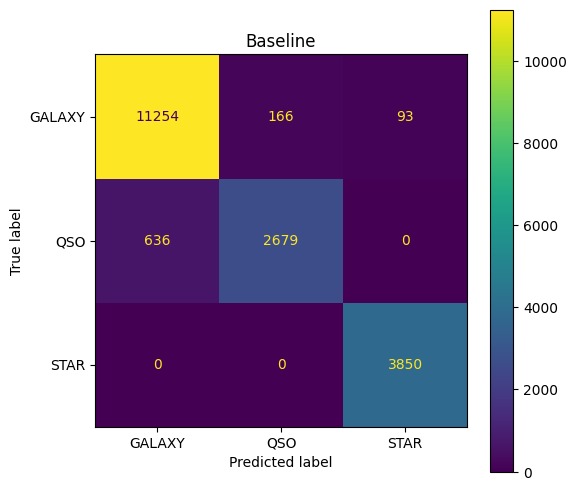

In [23]:
c1 = best_cortes[0] # 0.004163265306122449
c2 = best_cortes[1] # 0.9982448979591837

bins = [-np.inf, c1, c2, np.inf]
labels = ['STAR', 'GALAXY', 'QSO']

preds = pd.cut(test_df['redshift'], bins=bins, labels=labels)
preds = le.transform(preds)

show_metrics(y_test, preds, cm_classes=le.classes_, cm_title="Baseline")

Se observa una porcentaje de precisión balanceada bastante alta (92.9%) para un "modelo" tan simple como el planteado. Conocer el poder predictivo del `redshift` nos será de utilidad para entender qué modelos de Machine Learning pueden resultar más apropiados para este problema en particular.

## 5. KNN

### 5.1. Aplicación inicial modelo

In [24]:
# se entrena modelo KNN primero con selección inicial manual de parámetros

knn = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance',         # le da más peso a los vecinos más cercanos
    metric='minkowski', p=1,    # p = 1 --> manhatan | p = 2 --> euclidiana
    algorithm='auto',           # va a usar el método según sean los datos
    n_jobs=-1
)

knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

In [25]:
# se calculan métricas
# Accuracy
acc = accuracy_score(y_test, y_pred)

# F1-score
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

# Precision y Recall
precision_macro = precision_score(y_test, y_pred, average='macro')
recall_macro = recall_score(y_test, y_pred, average='macro')

print("Accuracy:", acc)
print("F1 (macro):", f1_macro)                  # macro: son promediadas las métricas de cada clase
print("F1 (weighted):", f1_weighted)            # este promedio es ponderado por la cantidad de datos de cada clase
print("Precision (macro):", precision_macro)
print("Recall (macro):", recall_macro)

Accuracy: 0.9512795802548453
F1 (macro): 0.9444297163936972
F1 (weighted): 0.9513135302326133
Precision (macro): 0.9467238604878342
Recall (macro): 0.9426173506990588


### 5.2. Optimización de hiperparámetros

In [26]:
# se aplica grid search para la búsqueda de hiperparámetros óptimos

param_grid = {
    'n_neighbors': [3, 5, 7, 11, 15, 19],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]   # 1 = Manhattan, 2 = Euclidiana
}

knn = KNeighborsClassifier()

grid = GridSearchCV(
    knn,
    param_grid,
    cv=5,
    scoring='f1_macro',   # importante en multiclase
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)


best_knn = grid.best_estimator_
y_pred_best = best_knn.predict(X_test_scaled)

print("Mejores parámetros:", grid.best_params_)

Mejores parámetros: {'n_neighbors': 3, 'p': 1, 'weights': 'uniform'}


In [27]:
# Accuracy
acc = accuracy_score(y_test, y_pred_best)

# F1-score
f1_macro = f1_score(y_test, y_pred_best, average='macro')
f1_weighted = f1_score(y_test, y_pred_best, average='weighted')

# Precision y Recall
precision_macro = precision_score(y_test, y_pred_best, average='macro')
recall_macro = recall_score(y_test, y_pred_best, average='macro')

print("Accuracy:", acc)
print("F1 (macro):", f1_macro)                  # macro: son promediadas las métricas de cada clase
print("F1 (weighted):", f1_weighted)            # este promedio es ponderado por la cantidad de datos de cada clase
print("Precision (macro):", precision_macro)
print("Recall (macro):", recall_macro)

Accuracy: 0.9495127958025484
F1 (macro): 0.9424976448080203
F1 (weighted): 0.9495316863198623
Precision (macro): 0.9448989175679667
Recall (macro): 0.9404814169429105


Se observa una leve disminución en las métricas de desempeño tras aplicar los hiperparámetros óptimos obtenidos mediante Grid Search para el modelo KNN. A priori, podría esperarse que la optimización de hiperparámetros conduzca a una mejora en los resultados, por lo que este comportamiento resulta contraintuitivo. Asimismo, llama la atención que la búsqueda no haya seleccionado la configuración inicial, aun cuando esta se encontraba incluida dentro del espacio explorado.

No obstante, esta diferencia puede explicarse por la metodología utilizada en el proceso de optimización. Mientras que el modelo inicial fue evaluado sobre un único train-test split, el Grid Search emplea validación cruzada, lo que implica evaluar cada combinación de hiperparámetros sobre múltiples particiones del conjunto de entrenamiento.

En este sentido, es posible que la configuración inicial se encuentre levemente ajustada a la partición específica utilizada, mientras que los hiperparámetros seleccionados por Grid Search representan una solución más robusta, orientada a mejorar la capacidad de generalización del modelo frente a datos no observados.

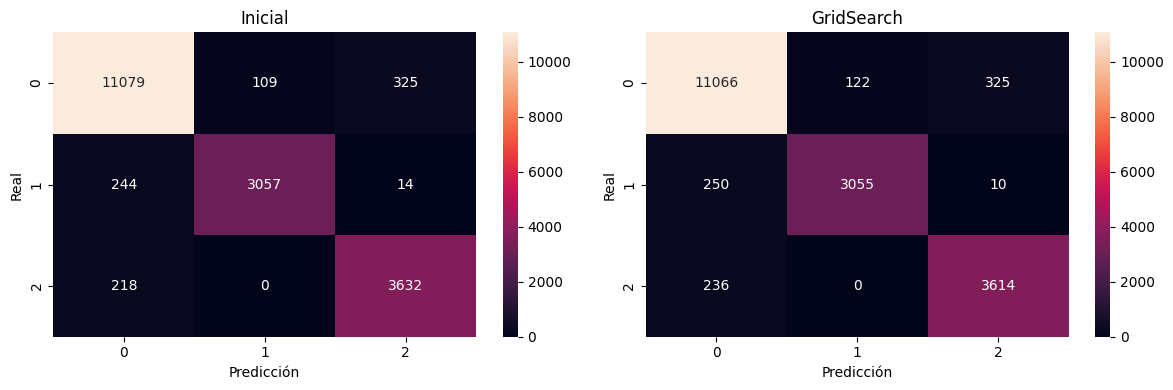

In [28]:

cm_inicial = confusion_matrix(y_test, y_pred)
cm_grid = confusion_matrix(y_test, y_pred_best)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Primera matriz (inicial)
sns.heatmap(cm_inicial, annot=True, fmt='d', ax=axes[0])
axes[0].set_title("Inicial")
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Real")

# Segunda matriz (grid)
sns.heatmap(cm_grid, annot=True, fmt='d', ax=axes[1])
axes[1].set_title("GridSearch")
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Real")

plt.tight_layout()
plt.show()

Vuelve a validarse, esta vez mediante la comparación de las matrices de confusón que la aplicación de los hiperparámetros óptimos no arroja una mejora.

Finalmente, se concluye que a los fines de la implementación del modelo para este trabajo, KNN con los parámetros inicialmente seleccionados es más que satisfactorio. Sin embargo, a los fines de un modelo productivo podrían priorizarse los encontrados mediante Grid Search.

## 6. SVM

### 6.1. Modelo básico

Para iniciar, se plantea un SVM básico, usando las configuraciones por defecto.

In [29]:
svm_base = SVC() # C=1.0 ; kernel='rbf'
svm_base.fit(X_train_scaled, y_train)

y_pred = svm_base.predict(X_test_scaled)

Accuracy: 0.9658421672555948
F1 (macro): 0.9602093222069156
F1 (weighted): 0.9657550913650168
Precision (macro): 0.9599080108994702
Recall (macro): 0.9615761289829989


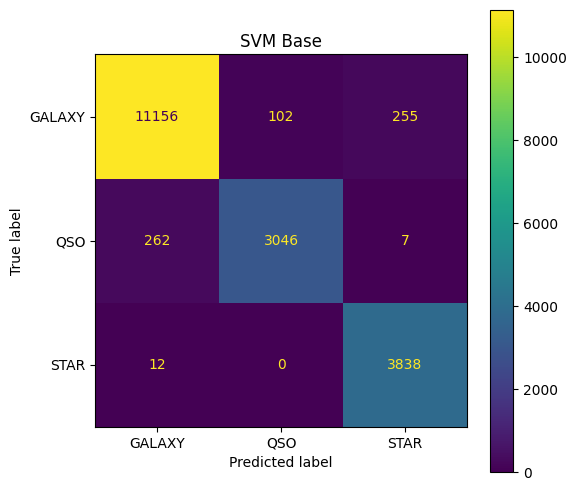

In [30]:
show_metrics(y_test, y_pred, cm_classes=le.classes_, cm_title="SVM Base")

### 6.2. Búsqueda de hiperparámetros


Con el objetivo de explorar las combinaciones de hiperparámetros que otorguen el mejor desempeño de este modelo, se implementa una optimización bayesiana, usando el framework Optuna.

En un primer intento, se ejecutó la optimización con el dataset de train completo, lo que llevó a demoras muy altas en algunas iteraciones de la búsqueda, y posteriormente a interrumpir la optimización por falta de respuesta. Debido a esto se toma un subconjunto más pequeño de este dataset sampleado aleatoriamente para obtener los hiperparámetros, lo que podría ocasionar que finalmente no se obtengan los mejores pero es una aproximación aceptable, por lo menos durante esta etapa de relevamiento de modelos (además de que igualemente no había garantía de obtenerlos por la optimización en sí).

In [31]:
n_samples = 20000

X_train_sub, y_train_sub = resample(
    X_train_scaled,
    y_train,
    n_samples=n_samples,
    replace=False,
    random_state=42,
    stratify=y_train
)

In [32]:
def objective(trial):
    # Definir el espacio de búsqueda para los hiperparámetros
    C = trial.suggest_float('C', 1e-4, 1e4, log=True)
    kernel = trial.suggest_categorical('kernel', ['linear', 'poly', 'rbf', 'sigmoid'])

    # Hiperparámetros que dependen del kernel elegido
    if kernel in ['rbf', 'poly', 'sigmoid']:
        gamma = trial.suggest_categorical('gamma', ['scale', 'auto'])
    else:
        gamma = 'scale' # Valor por defecto para kernel lineal

    degree = trial.suggest_int('degree', 2, 5) if kernel == 'poly' else 3

    # Instanciar el modelo con los hiperparámetros sugeridos con la prueba actual
    clf = SVC(
        C=C,
        kernel=kernel,
        gamma=gamma,
        degree=degree,
        random_state=42
    )

    # Evaluar el modelo, usando validación cruzada
    scores = cross_val_score(clf, X_train_sub, y_train_sub, cv=5, scoring='f1_macro', n_jobs=-1, verbose=3)

    # Devolver la métrica a optimizar
    return scores.mean()

In [ ]:
# Dirección: maximizar la métrica elegida (accuracy)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20, show_progress_bar=True, timeout=3600)

print("Mejores hiperparámetros encontrados:", study.best_params)
print("Mejor puntuación de validación cruzada:", study.best_value)

[I 2026-04-26 22:42:38,101] A new study created in memory with name: no-name-f90423bf-c207-4baf-bcbd-92a5865975c3


  0%|          | 0/20 [00:00<?, ?it/s]

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   49.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


[I 2026-04-26 22:43:27,915] Trial 0 finished with value: 0.6973225470871968 and parameters: {'C': 0.03136507269882425, 'kernel': 'sigmoid', 'gamma': 'auto'}. Best is trial 0 with value: 0.6973225470871968.


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   33.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


...

[I 2026-04-26 22:49:04,114] Trial 9 finished with value: 0.9316668904932965 and parameters: {'C': 0.2983612686986777, 'kernel': 'rbf', 'gamma': 'scale'}. Best is trial 6 with value: 0.9604421647477419.


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  3.1min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


[I 2026-04-26 22:52:09,504] Trial 10 finished with value: 0.9566722009683101 and parameters: {'C': 9094.739216950025, 'kernel': 'rbf', 'gamma': 'scale'}. Best is trial 6 with value: 0.9604421647477419.


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  3.5min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


[I 2026-04-26 22:55:42,230] Trial 11 finished with value: 0.9565907855219162 and parameters: {'C': 9792.141944771629, 'kernel': 'rbf', 'gamma': 'scale'}. Best is trial 6 with value: 0.9604421647477419.


In [ ]:
# Usar este si se ejecutó la optimización ================================
# best_svm = SVC(**study.best_params, random_state=42)
# ========================================================================

# Ejecutar este para usar los parámetros obtenidos en otra ejecución =====
best_svm = SVC(C=1393.569486, kernel='rbf', gamma='auto', random_state=42)
# ========================================================================

best_svm.fit(X_train_scaled, y_train)

# Evaluar en test con este nuevo modelo
y_pred = best_svm.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)



In [ ]:
show_metrics(y_test, y_pred, le.classes_)

### 6.3. Evaluación sin Redshift


Durante la evaluación del Baseline, se observó que el feature Redshift tenía un poder predictivo inmenso sobre las clases del target, tal que implementando un modelo optimizado como el anterior solo se pudo mejorar la precisión entre un 4% o 5%. Entonces, algo interesante para explorar es el comportamiento de los modelos eliminando este feature y observar cómo los demás predicen las clases.

De la misma manera, que se hizo para el SVM anterior, se hace una búsqueda con Optuna y se entrena.

In [ ]:
# El redshift corresponde a la última columna
r_ind = -1
X_train_sr = np.delete(X_train_scaled, r_ind, axis=1)
X_test_sr = np.delete(X_test_scaled, r_ind, axis=1)

n_samples = 5000

X_train_sub, y_train_sub = resample(
    X_train_sr,
    y_train,
    n_samples=n_samples,
    replace=False,
    random_state=42,
    stratify=y_train
)

def objective(trial):
    # Definir el espacio de búsqueda para los hiperparámetros
    C = trial.suggest_float('C', 1e-4, 1e4, log=True)
    kernel = trial.suggest_categorical('kernel', ['linear', 'poly', 'rbf', 'sigmoid'])

    # Hiperparámetros que dependen del kernel elegido
    if kernel in ['rbf', 'poly', 'sigmoid']:
        gamma = trial.suggest_categorical('gamma', ['scale', 'auto'])
    else:
        gamma = 'scale' # Valor por defecto para kernel lineal

    degree = trial.suggest_int('degree', 2, 5) if kernel == 'poly' else 3

    # Instanciar el modelo con los hiperparámetros sugeridos con la prueba actual
    clf = SVC(
        C=C,
        kernel=kernel,
        gamma=gamma,
        degree=degree,
        random_state=42
    )

    # Evaluar el modelo, usando validación cruzada
    scores = cross_val_score(clf, X_train_sub, y_train_sub, cv=5, scoring='f1_macro', n_jobs=-1, verbose=3)

    # Devolver la métrica a optimizar
    return scores.mean()

# Descomentar este si se quiere ejecutar la optimización==============
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20, show_progress_bar=True, timeout=3600)

print("Mejores hiperparámetros encontrados:", study.best_params)
print("Mejor puntuación de validación cruzada:", study.best_value)

best_svm = SVC(**study.best_params, random_state=42)
# =====================================================================

# Descomentar este para usar los parámetros obtenidos antes ===========
# best_svm = SVC(C=842.7883263573856, kernel='rbf', gamma='auto')
# =====================================================================
best_svm.fit(X_train_sr, y_train)

# Evaluar en test con este nuevo modelo
y_pred = best_svm.predict(X_test_sr)

show_metrics(y_test, y_pred, le.classes_)

Se observa una puntuación peor que el modelo base pero más que aceptable.

##  7. Decision Tree

### 7.1 Modelo Base



En esta sección, se probaran Árboles de decisión para poder estudiar el dataset y concluir si es un buen método de analisis.

Empezaremos el análisis solo con las variables físicas, y luego se agregarán las variables relacionadas al instrumento para analizar si aportan valor predictivo o no.

In [ ]:
features_fisicas = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
# Creamos el arbol base
# max_depth = 5 para no tener una profundidad demasiado grande
tree_base = DecisionTreeClassifier(max_depth=5, random_state=42)

# Lo entrenamos
tree_base.fit(X_train, y_train)

# Empezamos con predicción
y_pred = tree_base.predict(X_test)

# 2. Vemos la precisión
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# 3. El reporte detallado (Precision y Recall por cada clase)
print("\n--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred))

# 4. Importancia de las variables (Acá vemos qué mira el árbol)
importances = pd.Series(tree_base.feature_importances_, index=features_fisicas).sort_values(ascending=False)
print("\n--- Valor predictivo de las features ---")
print(importances)


# 5. Revisamos las metricas
show_metrics(y_test, y_pred, cm_classes=le.classes_)

Podemos ver que claramente el árbol practicamente solo utiliza redshift para predecir, y casi no mira las demas variables, lo cual lo vuelve un modelo "muy vago", esto se debe al alto poder predictivo de esta variable.

Sin embargo, a pesar de esto obtuvimos buenos valores de precisión, y la matriz de confusion quedó bastante bien... Como un detalle podemos ver que el punto donde mas se equivoca es en predecir Galaxy cuando en realidad es un Quasar.

### 7.2 Agregamos features tecnicas
Ahora empezaremos a agregar las demás variables que tienen que están relacionadas con el instrumento que se utilizó para obtener la medición, y analizaremos como afectan a la prediccion.

In [ ]:
# 1. Agregamos features tecnicas a todo lo anterior
features_final_arbol = [
    'alpha', 'delta', 'u', 'g', 'r', 'i', 'z',
    'redshift', 'plate', 'cam_col', 'run_ID', 'field_ID'
]
# Nota: 'plate', 'run_ID', 'field_ID' y 'cam_col' son identificadores de equipo.
# El modelo los usa para agrupar los datos que se tomaron juntos o con el mismo
# sensor, detectando patrones técnicos que ayudan a clasificar mejor.

# 2. Recortamos los dataframes
X_train_f = train_df[features_final_arbol]
X_test_f = test_df[features_final_arbol]

# 3. Entrenamos el árbol final (usamos y_train codificado)
tree_final = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_final.fit(X_train_f, y_train)
y_pred_final = tree_final.predict(X_test_f)

# 4. Vemos las importancias una última vez
importances_final = pd.Series(tree_final.feature_importances_, index=features_final_arbol).sort_values(ascending=False)
print("--- Importancia de Variables Final (Árbol Único) ---")
print(importances_final)

# 5. Revisamos metricas
show_metrics(y_test, y_pred_final, cm_classes=le.classes_)

In [ ]:
from sklearn.tree import export_graphviz
export_graphviz(tree_final, out_file = "arbol_con_todas.dot",
                feature_names=[
    'alpha', 'delta', 'u', 'g', 'r', 'i', 'z',
    'redshift', 'plate', 'cam_col', 'run_ID', 'field_ID'
],
                rounded=True,
                filled=True)

Como era de esperarse, ninguna de las variables técnicas agregadas posee algún valor predictivo fuerte o relevante para el análisis, el modelo se queda con el `redshift` y a partir de ahi predice. Esto es bueno por un lado, ya que el modelo es poco inmune al ruido que podrían introducir otras variables no relacionadas. De esta manera, tampoco se logra mejorar la precisión al agregarlas, por lo que el modelo empieza a alcanzar un límite en 0,96 de precisión.

## 8. Random Forest

### 8.1 Modelo con todas las features
Ahora implementaremos un modelo tipo Random Forest, para ver si se puede mejorar lo obtenido con el árbol de decisión simple.

In [ ]:
# 1. Definimos la lista completa de variables
features_totales = [
    'alpha', 'delta', 'u', 'g', 'r', 'i', 'z',
    'redshift', 'plate', 'cam_col', 'run_ID', 'field_ID'
]

# 2. Recortamos de los dataframes
X_train_rf = train_df[features_totales]
X_test_rf = test_df[features_totales]

# 3. Creamos y entrenamos el Random Forest
rf_final = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_final.fit(X_train_rf, y_train)

# 4. Predicciones
y_pred_rf = rf_final.predict(X_test_rf)

# 5. Extraemos las importancias del modelo
importances = pd.Series(rf_final.feature_importances_, index=features_totales).sort_values(ascending=False)
print("--- Importancia de Variables---")
print(importances)
print("\n" + "="*40 + "\n")

# 6. Evaluamos las metricas
show_metrics(y_test, y_pred_rf, cm_classes=le.classes_)

A diferencia del árbol simple, el random forest presenta una distribución de relevancia mucho mas equilibrada entre sus variables. Si bien el redshift sigue siendo la variable principal para predecir, paso de tener un 0,95 de relevancia a tener un 0,61 permitiendo asi que las demas variables tomen mas peso en la toma de decisiones. Esta 'democracia' que fomenta el Random Forest resulta muy beneficiosa para las métricas del modelo, ya que permite capturar la complejidad de predicción de los Quasars que teníamos inicialmente con el Árbol de Decisión simple.

### 8.2 Random Forest de features físicas
Se prueba ahora el RandomForest pero usando solo las features físicas del principio, es decir, aquellas que corresponden solo a la medición del objeto, para ver si las features técnicas aportan valor predictivo real al sistema o solo ruido.

In [ ]:
# 1. Definición de variables físicas
features_fisicas = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']

# 2. Recorte de los conjuntos de entrenamiento y prueba
X_train_rf_fisicas = train_df[features_fisicas]
X_test_rf_fisicas = test_df[features_fisicas]

# 3. Creación y entrenamiento del modelo Random Forest
rf_fisicas = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_fisicas.fit(X_train_rf_fisicas, y_train)

# 4. Generación de predicciones
y_pred_rf_fisicas = rf_fisicas.predict(X_test_rf_fisicas)

# 5. Análisis de importancia de variables
importances_fisicas = pd.Series(rf_fisicas.feature_importances_, index=features_fisicas).sort_values(ascending=False)
print("--- Importancia de Variables (RF - Solo Físicas) ---")
print(importances_fisicas)
print("\n" + "="*40 + "\n")

# 6. Evaluación de métricas
show_metrics(y_test, y_pred_rf_fisicas, cm_classes=le.classes_)

Vemos que obtenemos casi el mismo resultado, lo que quiere decir que las features técnicas aportan mas ruido que valor predictivo, por lo que se mantienen únicamente solo las features físicas para el análisis. Conceptualmente, es lo que tiene más sentido pero al esto permite asegurarnos que no existen sesgos asociados al instrumento.

### 8.3 Optuna
 Ahora utilizaremos Optuna para encontrar los hiperparámetros que optimicen el Random Forest.

In [ ]:
# 1. DEFINIMOS LA FUNCIÓN OBJETIVO
def objective(trial):
    # --- Espacio de búsqueda (Acá Optuna decide qué probar) ---
    # Le decimos entre qué valores puede "adivinar"
    n_estimators = trial.suggest_int('n_estimators', 50, 200) # De 50 a 200 árboles
    max_depth = trial.suggest_int('max_depth', 5, 30)         # Profundidad máxima
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)

    # --- Creamos el modelo con los parámetros que Optuna eligió en este "Trial" ---
    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42,
        n_jobs=-1 # Para usar todos los núcleos de tu compu y que vaya rápido
    )

    # --- Entrenamos ---
    rf.fit(X_train_rf, y_train)

    # --- Predecimos y Evaluamos ---
    scores = cross_val_score(rf, X_train_rf, y_train, cv=5, scoring='accuracy', n_jobs=-1)

    # Le devolvemos el Accuracy a Optuna para que aprenda
    return scores.mean()

# 2. CREAMOS EL ESTUDIO Y LO PONEMOS A TRABAJAR
print("Arranca Optuna a buscar los mejores parámetros")
# Queremos MAXIMIZAR el accuracy
study = optuna.create_study(direction='maximize')

# n_trials=50 significa que va a probar 50 configuraciones distintas.
# study.optimize(objective, n_trials=50)
# Dejo comentada esta linea, mas abajo se sigue trabajando con el mejor modelo encontrado por Optuna


# 3. MOSTRAMOS LOS RESULTADOS
print("\n--- ¡BÚSQUEDA TERMINADA! ---")
print(f"Mejor Accuracy encontrado: {study.best_value:.4f}")
print("Mejores Hiperparámetros encontrados:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

In [ ]:
# 1. Creación del modelo definitivo con los parámetros obtenidos en la optimización
rf_optimo = RandomForestClassifier(
    n_estimators=94,
    max_depth=21,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

# 2. Entrenamiento del modelo final
rf_optimo.fit(X_train_rf, y_train)

# 3. Generación de predicciones sobre el conjunto de prueba
y_pred_optimo = rf_optimo.predict(X_test_rf)

# 4. Evaluación de métricas
show_metrics(y_test, y_pred_optimo, cm_classes=le.classes_)

Conclusion Final:

El valor de la información instrumental: Observamos empíricamente que utilizar únicamente variables físicas (como el redshift o los filtros de luz) limitaba el desempeño de nuestros modelos basicos. Al incorporar el Random Forest se logró contextualizar mejor las mediciones, reduciendo la confusión, especialmente entre las clases QSO (Quásares) y STAR (Estrellas).


Prevención del Data Leakage: Gracias a la implementación de GroupShuffleSplit basado en el obj_ID, garantizamos que las múltiples observaciones de un mismo objeto celeste no contaminaran el conjunto de validación.


Optuna: Finalmente una vez encontrado el mejor setup para nuestro modelo, utilizamos Optuna para encontrar los mejores parametros y asi exprimir al maximo el modelo, obteniendo asi un excelente modelo de 0,9821 de Accuracy

## 9. Boosting con XGBoost

Se implementa un modelo de boosting, particularmente XGBoost para evaluar su desempeño. Se observó que el XGBClassifier tiene muchos parámetros a configurar y que interactúan entre sí. Por este motivo, se hace una búsqueda bayesiana de hiperparámetros, mediante Optuna, que resulta más práctico que una búsqueda de grilla.

In [ ]:
n_samples = 10000
X_train_sub, y_train_sub = resample(
    X_train_scaled,
    y_train,
    n_samples=n_samples,
    replace=False,
    random_state=42,
    stratify=y_train
)

def objective(trial):
    params = {
        # Ensamble y aprendizaje
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),

        # Complejidad del árbol
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5.0),

        # Subsampling
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),

        # Regularización
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),

        # Fijos
        'objective': 'multi:softmax',
        'num_class': 3,
        'random_state': 42,
        'n_jobs': -1,
        'eval_metric': 'mlogloss',
    }

    clf = xgb.XGBClassifier(**params)

    scores = cross_val_score(
        clf, X_train_sub, y_train_sub,
        cv=5, scoring='accuracy', n_jobs=-1
    )

    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=25, show_progress_bar=True, timeout=3600)

print("Mejores hiperparámetros encontrados:", study.best_params)
print("Mejor puntuación de validación cruzada:", study.best_value)


In [ ]:
# Mejores hiperparámetros encontrados: {'n_estimators': 471, 'learning_rate': 0.018850609797582824, 'max_depth': 7, 'min_child_weight': 4, 'gamma': 0.5362773100776411, 'subsample': 0.7057408639743612, 'colsample_bytree': 0.6554406985045177, 'reg_alpha': 0.03857290302791919, 'reg_lambda': 1.064183042415151}
best_xgb = xgb.XGBClassifier(
    **study.best_params,
    objective='multi:softmax',
    num_class=3,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)
best_xgb.fit(X_train_scaled, y_train)

y_pred = best_xgb.predict(X_test_scaled)

In [ ]:
show_metrics(y_test, y_pred, le.classes_)

Las métricas de XGBoost están por debajo del Random Forest en una cantidad casi despreciable e incluso es posible que esto se deba al hecho de haber realizado la optimización de hiperparámetros usando solo una muestra del dataset.

## 10. Conclusiones

Se recompilan las puntuaciones logradas por cada modelo en la siguiente tabla:

| Modelo | Accuracy | F1 Macro | F1 Weighted | Precision Macro | Recall Macro |
| --- | --- | ---- | --- | --- | --- |
| Baseline | 0.9521 | 0.9399 | 0.9509 | 0.9549 | 0.9285 |
| KNN | 0.9513 | 0.9444 | 0.9513 | 0.9467 | 0.9426 |
| KNN + GridSearch | 0.9495 | 0.9424 | 0.9495 | 0.9448 | 0.9404 |
| SVM Default | 0.9616 | 0.9602 | 0.9658 | 0.9599 | 0.9616 |
| SVM + Optuna | 0.9751 | 0.9704| 0.9750| 0.9721 | 0.9688 |
| SVM(sin Redshift) | 0.8541 | 0.8490 | 0.8874 | 0.8612 | 0.8399 |
| Decision Tree | 0.9683 | 0.9603 | 0.9677 | 0.9722 | 0.9502 |
| Random Forest | 0.9823 | 0.9785 | 0.9822 | 0.9810 | 0.9762 |
| XGBoost + Optuna | 0.9723 | 0.9752 | 0.9792 | 0.9781 | 0.9723 |


Durante el análisis exploratorio de los datos, se identificó que la variable redshift posee un alto poder discriminante entre las clases. Esto permitió construir un modelo base relativamente simple con un desempeño elevado (superior al 92% de precisión), lo cual sugiere que una parte significativa del problema puede resolverse a partir de esta única dimensión. Sin embargo, este resultado también establece un baseline exigente para el resto de los modelos, dado que cualquier mejora adicional requiere capturar información más sutil presente en el resto de las variables.

A lo largo de la experimentación con distintos algoritmos, se observó que los modelos basados en árboles, en particular Random Forest, alcanzan el mejor desempeño (F1 macro cercano a 0.98), seguidos por métodos de boosting como XGBoost. Este comportamiento es consistente con la naturaleza del problema, ya que estos modelos son especialmente eficaces para capturar relaciones no lineales e interacciones complejas entre variables, algo esperable en datos astronómicos donde las clases no se separan mediante fronteras simples.

Un aspecto relevante es que, si bien redshift concentra gran parte de la señal, los modelos de ensamble no dependen exclusivamente de esta variable. El mecanismo de selección aleatoria de atributos en Random Forest permite construir árboles que exploran distintas combinaciones de variables, incorporando información complementaria proveniente de las bandas fotométricas (u, g, r, i, z) y coordenadas. Esto explica el salto de desempeño respecto a modelos más simples o locales como KNN o modelos con fronteras globales como SVM.

Para validar la contribución del resto de las variables, se realizó un experimento adicional excluyendo redshift. Los resultados mostraron que, si bien el desempeño disminuye, las demás variables mantienen una capacidad predictiva relevante. Esto indica que la clasificación no depende exclusivamente de una única feature, sino de la interacción entre múltiples mediciones físicas.

Finalmente, si bien algunos modelos fueron entrenados inicialmente sobre subconjuntos de datos debido a limitaciones computacionales de Colab, las pruebas realizadas sobre el dataset completo en entornos locales confirmaron la estabilidad de los resultados y las conclusiones obtenidas.

En síntesis, el análisis muestra que en problemas donde existe una variable dominante pero también interacciones no lineales entre múltiples features, los modelos de ensamble basados en árboles, particularmente Random Forest, resultan altamente efectivos, ya que logran combinar la señal principal con información secundaria distribuida en el resto de las variables, alcanzando así un desempeño superior y robusto.